In [1]:
import torch
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("🟦 --- VÉRIFICATION MATÉRIELLE KAGGLE ---")
print(f"🔥 GPU Principal : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'AUCUN (Vérifie tes réglages à droite)'}")
if torch.cuda.device_count() > 1:
    print(f"🚀 GPU Secondaire détecté : {torch.cuda.get_device_name(1)}")

🟦 --- VÉRIFICATION MATÉRIELLE KAGGLE ---
🔥 GPU Principal : Tesla T4
🚀 GPU Secondaire détecté : Tesla T4


Chargement des labels en cours...
Nombre de termes uniques trouvés : 31466

Les 10 termes les plus fréquents (ceux que l'IA apprendra en priorité) :
term
GO:0005575    92912
GO:0008150    92210
GO:0110165    91286
GO:0003674    78637
GO:0005622    70785
GO:0009987    61293
GO:0043226    60883
GO:0043229    58315
GO:0005488    57380
GO:0043227    55452
Name: count, dtype: int64


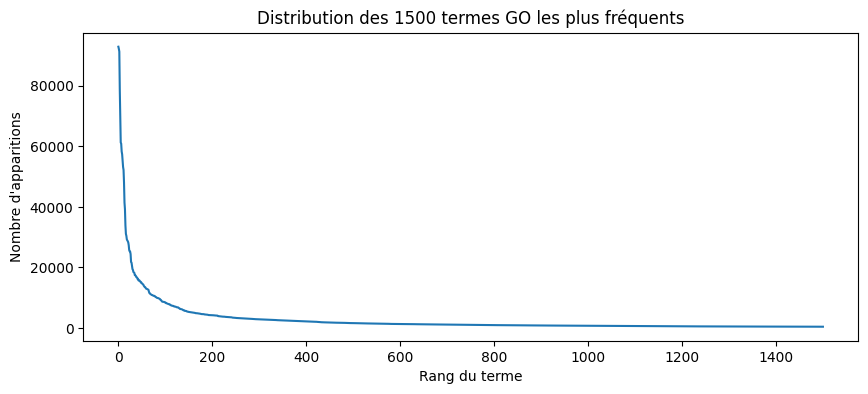

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Chargement intelligent (on ne lit que les colonnes nécessaires pour gagner de la RAM)
# Note : Remplace 'train_terms.tsv' par le chemin exact de ton fichier
print("Chargement des labels en cours...")
train_terms = pd.read_csv('/kaggle/input/datasets/iliassouchida/cafa-5-protein-function-prediction/Train/train_terms.tsv', sep="\t")

# 2. Identification des 1500 termes les plus fréquents
top_1500_terms = train_terms['term'].value_counts().head(1500)

print(f"Nombre de termes uniques trouvés : {len(train_terms['term'].unique())}")
print("\nLes 10 termes les plus fréquents (ceux que l'IA apprendra en priorité) :")
print(top_1500_terms.head(10))

# 3. Visualisation de la "Longue Traîne" (Optionnel mais recommandé pour ton rapport)
plt.figure(figsize=(10, 4))
plt.plot(range(1500), top_1500_terms.values)
plt.title('Distribution des 1500 termes GO les plus fréquents')
plt.xlabel('Rang du terme')
plt.ylabel('Nombre d\'apparitions')
plt.show()

In [3]:
pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 38.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install --upgrade pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 24.0 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
Note: you may need to restart the kernel to use updated packages.


In [5]:
from Bio import SeqIO
import pandas as pd

# On lit le fichier FASTA
fasta_data = []
for record in SeqIO.parse("/kaggle/input/datasets/iliassouchida/cafa-5-protein-function-prediction/Train/train_sequences.fasta", "fasta"):
    fasta_data.append({'EntryID': record.id, 'sequence': str(record.seq)})

# On crée un DataFrame avec toutes les séquences
df_seqs = pd.DataFrame(fasta_data)
print(f"Nombre de séquences trouvées : {len(df_seqs)}")

Nombre de séquences trouvées : 142246


In [6]:
# --- 1. CRÉATION DES LABELS (Y) ---
# On récupère les noms des 1500 termes les plus fréquents
target_terms = top_1500_terms.index.tolist()

# On filtre le fichier train_terms original pour ne garder que ces 1500 termes
train_terms_filtered = train_terms[train_terms['term'].isin(target_terms)]

# On crée la matrice pivot (Lignes = Protéines, Colonnes = Termes)
# On met 1 si la protéine a le terme, sinon 0
print("Création de la matrice pivot (Y_pivot)...")
Y_pivot = train_terms_filtered.pivot_table(index='EntryID', columns='term', aggfunc='size', fill_value=0)
Y_pivot = (Y_pivot > 0).astype(int)

# --- 2. FUSION (MERGE) ---
# Maintenant on fusionne avec df_seqs que tu as déjà créé
print("Fusion avec les séquences en cours...")
df_final = pd.merge(df_seqs, Y_pivot, on='EntryID', how='inner')

print("\n--- RÉSULTAT FINAL ---")
print(f"Nombre de protéines (lignes) : {df_final.shape[0]}")
print(f"Nombre de colonnes : {df_final.shape[1]}")

Création de la matrice pivot (Y_pivot)...
Fusion avec les séquences en cours...

--- RÉSULTAT FINAL ---
Nombre de protéines (lignes) : 142246
Nombre de colonnes : 1502


In [7]:
print("--- EXPLORATION : DONNÉES FUSIONNÉES ---")
# On affiche l'ID, la séquence (tronquée) et les 3 premiers termes GO
df_final.iloc[:5, :5]

--- EXPLORATION : DONNÉES FUSIONNÉES ---


,EntryID,sequence,GO:0000003,GO:0000041,GO:0000070
0,P20536,MNSVTVSHAPYTITYHDDWEPVMSQLVEFYNEVASWLLRDETSPIP...,0,0,0
1,O73864,MTEYRNFLLLFITSLSVIYPCTGISWLGLTINGSSVGWNQTHHCKL...,0,0,0
2,O95231,MRLSSSPPRGPQQLSSFGSVDWLSQSSCSGPTHTPRPADFSLGSLP...,0,0,0
3,A0A0B4J1F4,MGGEAGADGPRGRVKSLGLVFEDESKGCYSSGETVAGHVLLEAAEP...,0,0,0
4,P54366,MVETNSPPAGYTLKRSPSDLGEQQQPPRQISRSPGNTAAYHLTTAM...,0,0,0


In [8]:
# Compter le nombre de fonctions (colonnes à 1) pour chaque protéine
# On ignore les colonnes 0 (ID) et 1 (Séquence)
fonctions_par_proteine = df_final.iloc[:, 2:].sum(axis=1)

print("--- STATISTIQUES DES LABELS ---")
print(f"Nombre moyen de fonctions par protéine : {fonctions_par_proteine.mean():.2f}")
print(f"Maximum de fonctions pour une protéine : {fonctions_par_proteine.max()}")
print(f"Minimum de fonctions pour une protéine : {fonctions_par_proteine.min()}")

--- STATISTIQUES DES LABELS ---
Nombre moyen de fonctions par protéine : 31.08
Maximum de fonctions pour une protéine : 437
Minimum de fonctions pour une protéine : 1


In [9]:
print("--- EXPLORATION : LABELS (BRUTS) ---")
print(f"Nombre total d'annotations : {len(train_terms)}")
print(f"Nombre de termes GO uniques : {train_terms['term'].nunique()}")
print(f"Nombre de protéines uniques annotées : {train_terms['EntryID'].nunique()}")
print("\nTop 5 des termes les plus fréquents :")
print(train_terms['term'].value_counts().head(5))

--- EXPLORATION : LABELS (BRUTS) ---
Nombre total d'annotations : 5363863
Nombre de termes GO uniques : 31466
Nombre de protéines uniques annotées : 142246

Top 5 des termes les plus fréquents :
term
GO:0005575    92912
GO:0008150    92210
GO:0110165    91286
GO:0003674    78637
GO:0005622    70785
Name: count, dtype: int64


In [10]:
print("--- EXPLORATION : SEQUENCES ---")
print(f"Nombre total de séquences : {len(df_seqs)}")
print(f"Longueur moyenne des protéines : {df_seqs['sequence'].apply(len).mean():.2f} acides aminés")
print("\nExtrait du fichier (3 premières lignes) :")
df_seqs.head(3)

--- EXPLORATION : SEQUENCES ---
Nombre total de séquences : 142246
Longueur moyenne des protéines : 553.64 acides aminés

Extrait du fichier (3 premières lignes) :


,EntryID,sequence
0,P20536,MNSVTVSHAPYTITYHDDWEPVMSQLVEFYNEVASWLLRDETSPIP...
1,O73864,MTEYRNFLLLFITSLSVIYPCTGISWLGLTINGSSVGWNQTHHCKL...
2,O95231,MRLSSSPPRGPQQLSSFGSVDWLSQSSCSGPTHTPRPADFSLGSLP...


In [11]:
# Calculer la longueur de chaque texte dans la colonne 'sequence'
df_final['longueur'] = df_final['sequence'].apply(len)

print("\n--- STATISTIQUES DES SÉQUENCES ---")
print(f"Longueur moyenne : {df_final['longueur'].mean():.1f} acides aminés")
print(f"Protéine la plus longue : {df_final['longueur'].max()}")
print(f"Protéine la plus courte : {df_final['longueur'].min()}")


--- STATISTIQUES DES SÉQUENCES ---
Longueur moyenne : 553.6 acides aminés
Protéine la plus longue : 35375
Protéine la plus courte : 3


In [12]:
# Compter les occurrences de chaque terme GO
comptage_termes = df_final.iloc[:, 2:-1].sum().sort_values(ascending=False)

print("\n--- ÉQUILIBRE DES CLASSES ---")
print("Top 5 des fonctions les plus fréquentes :")
print(comptage_termes.head(5))
print("\nTop 5 des fonctions les moins fréquentes (parmi tes 1500) :")
print(comptage_termes.tail(5))


--- ÉQUILIBRE DES CLASSES ---
Top 5 des fonctions les plus fréquentes :
GO:0005575    92912
GO:0008150    92210
GO:0110165    91286
GO:0003674    78637
GO:0005622    70785
dtype: int64

Top 5 des fonctions les moins fréquentes (parmi tes 1500) :
GO:0001818    431
GO:0031674    431
GO:0051783    431
GO:0016887    430
GO:0051048    430
dtype: int64


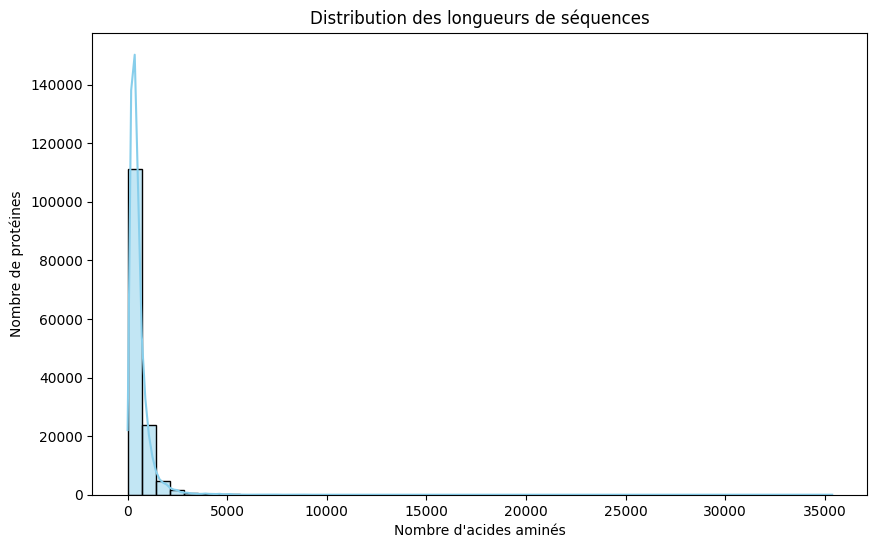

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculer la longueur de chaque séquence
longueurs = df_final['sequence'].apply(len)

plt.figure(figsize=(10, 6))
sns.histplot(longueurs, bins=50, kde=True, color='skyblue')
plt.title('Distribution des longueurs de séquences')
plt.xlabel('Nombre d\'acides aminés')
plt.ylabel('Nombre de protéines')
plt.show()

In [14]:
import numpy as np
import pandas as pd

print("🧹 --- ÉTAPE 1 : RETRAIT DES SÉQUENCES AMBIGUËS ---")

# Alphabet des 20 acides aminés standards
acides_standards = set('ACDEFGHIKLMNPQRSTVWY')

# Fonction pour valider si une séquence est 100% standard
def est_100_percent_standard(seq):
    return set(seq).issubset(acides_standards)

# Filtrage strict
df_final_clean = df_final[df_final['sequence'].apply(est_100_percent_standard)].copy()

print(f"Nombre de protéines initiales : {len(df_final)}")
print(f"Nombre de protéines conservées : {len(df_final_clean)}")
print(f"👉 Protéines supprimées (bruit) : {len(df_final) - len(df_final_clean)}")

🧹 --- ÉTAPE 1 : RETRAIT DES SÉQUENCES AMBIGUËS ---
Nombre de protéines initiales : 142246
Nombre de protéines conservées : 140569
👉 Protéines supprimées (bruit) : 1677


In [15]:
print("📊 --- ÉTAPE 2 : PRÉPARATION DE Y ET CALCUL DU NOMBRE DE FONCTIONS ---")

# 1. On isole les colonnes de labels GO
cols_go = [c for c in df_final_clean.columns if c.startswith('GO:')]
Y = df_final_clean[cols_go].values

# 2. TON IDÉE : Compter le nombre de '1' pour chaque protéine (somme sur les colonnes)
# axis=1 fait la somme horizontale, keepdims=True garde la forme d'une colonne (N, 1)
nb_fonctions_par_proteine = np.sum(Y, axis=1, keepdims=True)

print(f"Forme de la matrice cible Y : {Y.shape}")
print(f"Forme de ta nouvelle colonne (Comptage des 1) : {nb_fonctions_par_proteine.shape}")
print(f"Exemple du nombre de fonctions pour les 3 premières protéines :\n{nb_fonctions_par_proteine[:3]}")

📊 --- ÉTAPE 2 : PRÉPARATION DE Y ET CALCUL DU NOMBRE DE FONCTIONS ---
Forme de la matrice cible Y : (140569, 1500)
Forme de ta nouvelle colonne (Comptage des 1) : (140569, 1)
Exemple du nombre de fonctions pour les 3 premières protéines :
[[ 30]
 [137]
 [ 62]]


In [16]:
import torch
import time
import numpy as np
from transformers import AutoTokenizer, EsmModel

print("🧬 --- CHARGEMENT D'ESM-2 (META AI) EN MÉMOIRE ---")
model_name = "facebook/esm2_t30_150M_UR50D"

# Téléchargement et chargement des structures de l'IA de Meta
tokenizer = AutoTokenizer.from_pretrained(model_name)
model_embeddings = EsmModel.from_pretrained(model_name)

# Détection et bascule sur le GPU de Kaggle
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_embeddings = model_embeddings.to(device)
model_embeddings.eval() # Mode inférence pour bloquer le dropout

print(f"✅ ESM-2 chargé avec succès sur l'appareil : {device}")

🧬 --- CHARGEMENT D'ESM-2 (META AI) EN MÉMOIRE ---


config.json:   0%|          | 0.00/779 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/595M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t30_150M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ ESM-2 chargé avec succès sur l'appareil : cuda


In [17]:
import pandas as pd
from Bio import SeqIO
from tqdm import tqdm
import os

print("📊 Alignement des séquences avant encodage...", flush=True)
chemin_df = "/kaggle/input/datasets/iliassouchida/protbert-result/df_final_clean_sorted.csv"
df_csv = pd.read_csv(chemin_df)

chemin_fasta = "/kaggle/input/cafa-5-protein-function-prediction/Train/train_sequences.fasta"
for p in ["/kaggle/input/datasets/iliassouchida/cafa-5-protein-function-prediction/Train/train_sequences.fasta", 
          "/kaggle/input/datasets/cafa-5-protein-function-prediction/Train/train_sequences.fasta"]:
    if os.path.exists(p): chemin_fasta = p

# Alignement strict Séquence -> ID
fasta_dict = {str(record.seq): record.id for record in SeqIO.parse(chemin_fasta, "fasta")}
sequences_valides = [row['sequence'] for idx, row in df_csv.iterrows() if row['sequence'] in fasta_dict]

print(f"📋 Séquences prêtes pour ESM-2 : {len(sequences_valides)}")

# Paramètres d'extraction
batch_size = 32
embeddings_list = []

print("⚡ Extraction des features sémantiques ESM-2 sur GPU (Est: ~15 min)...")
with torch.no_grad():
    for i in tqdm(range(0, len(sequences_valides), batch_size)):
        batch_seqs = sequences_valides[i:i+batch_size]
        
        # Tokenisation avec coupure stricte à 1024 acides aminés
        inputs = tokenizer(batch_seqs, return_tensors="pt", padding=True, truncation=True, max_length=1024).to(device)
        
        # Passage dans le transformer de Meta AI
        outputs = model_embeddings(**inputs)
        hidden_states = outputs.last_hidden_state # Shape: (Batch, Longueur, 640)
        
        # Calcul du Mean Pooling intelligent (sans prendre en compte le rembourrage/padding)
        attention_mask = inputs['attention_mask'].unsqueeze(-1)
        hidden_states_actifs = hidden_states * attention_mask
        
        somme_embeddings = hidden_states_actifs.sum(dim=1)
        longueurs_reelles = attention_mask.sum(dim=1).clamp(min=1)
        mean_pooled = somme_embeddings / longueurs_reelles # Vectorisé en dimension 640
        
        embeddings_list.append(mean_pooled.cpu().numpy())

# Sauvegarde de la toute nouvelle matrice X
X_esm2 = np.vstack(embeddings_list)
np.save("X_esm2_clean.npy", X_esm2)

print("\n📊 =================================================================")
print(f"✨ Forme finale de ta nouvelle matrice X_esm2 : {X_esm2.shape}")
print(f"💾 Fichier 'X_esm2_clean.npy' sauvegardé ({os.path.getsize('X_esm2_clean.npy') / (1024*1024):.2f} MB).")
print("=====================================================================")

📊 Alignement des séquences avant encodage...
📋 Séquences prêtes pour ESM-2 : 140569
⚡ Extraction des features sémantiques ESM-2 sur GPU (Est: ~15 min)...


100%|██████████| 4393/4393 [2:35:22<00:00,  2.12s/it]



📊 =================================================================
✨ Forme finale de ta nouvelle matrice X_esm2 : (140569, 640)
💾 Fichier 'X_esm2_clean.npy' sauvegardé (343.19 MB).


In [18]:
from IPython.display import FileLink
import os

nom_matrice = "X_esm2_clean.npy"

if os.path.exists(nom_matrice):
    taille_mb = os.path.getsize(nom_matrice) / (1024 * 1024)
    print(f"✅ Nouvelle matrice ESM-2 détectée avec succès !")
    print(f"📦 Taille du fichier : {taille_mb:.2f} MB")
    print("⬇️ CLIQUE SUR LE LIEN CI-DESSOUS POUR LA TÉLÉCHARGER SUR TON PC :")
    
    # Génération du lien cliquable dans Kaggle
    display(FileLink(nom_matrice))
else:
    print(f"❌ Le fichier '{nom_matrice}' n'a pas encore été généré. Attends que la cellule d'extraction soit à 100% !")

✅ Nouvelle matrice ESM-2 détectée avec succès !
📦 Taille du fichier : 343.19 MB
⬇️ CLIQUE SUR LE LIEN CI-DESSOUS POUR LA TÉLÉCHARGER SUR TON PC :


/kaggle/working/X_esm2_clean.npy

📂 [ESM-2 MODE] Alignement des matrices de Meta AI...
✅ Matrices prêtes ! X (ESM-2): (140569, 640), Y: (140569, 1500)

🏋️‍♂️ Entraînement de l'architecture ResNet ESM-2...
📈 Époque 01/12 | Loss Train : 0.0375 | Loss Val : 0.0187
📈 Époque 02/12 | Loss Train : 0.0111 | Loss Val : 0.0103
📈 Époque 03/12 | Loss Train : 0.0107 | Loss Val : 0.0105
📈 Époque 04/12 | Loss Train : 0.0106 | Loss Val : 0.0105
📈 Époque 05/12 | Loss Train : 0.0105 | Loss Val : 0.0107
📈 Époque 06/12 | Loss Train : 0.0104 | Loss Val : 0.0106
📈 Époque 07/12 | Loss Train : 0.0104 | Loss Val : 0.0106
📈 Époque 08/12 | Loss Train : 0.0104 | Loss Val : 0.0106
📈 Époque 09/12 | Loss Train : 0.0103 | Loss Val : 0.0106
📈 Époque 10/12 | Loss Train : 0.0103 | Loss Val : 0.0106
📈 Époque 11/12 | Loss Train : 0.0103 | Loss Val : 0.0105
📈 Époque 12/12 | Loss Train : 0.0103 | Loss Val : 0.0105
🖼️ Graphique 'courbe_apprentissage_esm2.png' sauvegardé avec succès.


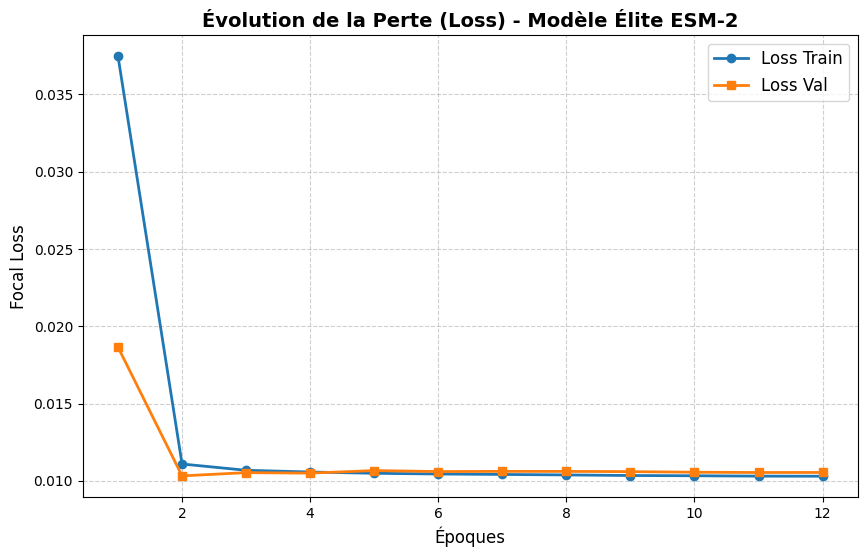


🔮 Recherche mathématique du seuil optimal...

📊 --- 🎯 ARCHITECTURE DE POINTE : PERFORMANCES DU RESNET ESM-2 🎯 ---
✨ Seuil de Décision Idéal     : 0.37
✨ Précision Binaire Globale   : 0.9743
✨ Précision Spécifique        : 0.3487
✨ Rappel Spécifique           : 0.2773
🔥 F1-SCORE FINAL RESNET ESM-2 : 0.3089 🚀🚀🚀


In [19]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import matplotlib.pyplot as plt

# 1. Alignement des données
print("📂 [ESM-2 MODE] Alignement des matrices de Meta AI...")
X_esm2 = np.load("X_esm2_clean.npy") 
print(f"✅ Matrices prêtes ! X (ESM-2): {X_esm2.shape}, Y: {Y.shape}")

X_train, X_val, y_train, y_val = train_test_split(X_esm2, Y, test_size=0.2, random_state=42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.float32))

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

# 2. Focal Loss
class PosterFocalLoss(nn.Module):
    def __init__(self, alpha=0.45, gamma=2.0):
        super(PosterFocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.bce = nn.BCEWithLogitsLoss(reduction='none')
    def forward(self, inputs, targets):
        bce_loss = self.bce(inputs, targets)
        pt = torch.exp(-bce_loss) 
        focal_loss = self.alpha * ((1 - pt) ** self.gamma) * bce_loss
        return focal_loss.mean()

# 3. Architecture ResNet (640 entrées)
class ResidualBlock1D(nn.Module):
    def __init__(self, channels):
        super(ResidualBlock1D, self).__init__()
        self.conv1 = nn.Conv1d(channels, channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(channels)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(channels)
        self.dropout = nn.Dropout1d(0.2)
        self.act = nn.SiLU()
    def forward(self, x):
        residual = x
        out = self.act(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        out += residual  
        return self.act(out)

class DeepProteinResNetESM(nn.Module):
    def __init__(self, output_dim):
        super(DeepProteinResNetESM, self).__init__()
        self.attention_net = nn.Sequential(nn.Linear(640, 160), nn.SiLU(), nn.Linear(160, 640))
        self.attn_norm = nn.LayerNorm(640)   
        self.input_dropout = nn.Dropout(0.3)  
        self.init_conv = nn.Conv1d(1, 256, kernel_size=7, padding=3)
        self.init_bn = nn.BatchNorm1d(256)
        self.act = nn.SiLU()
        self.res_block1 = ResidualBlock1D(256)
        self.res_block2 = ResidualBlock1D(256)
        self.res_block3 = ResidualBlock1D(256)
        self.pool = nn.AdaptiveAvgPool1d(16)  
        self.flatten = nn.Flatten()
        self.fc = nn.Sequential(
            nn.Linear(256 * 16, 1024), nn.BatchNorm1d(1024), nn.SiLU(), nn.Dropout(0.5),  
            nn.Linear(1024, 512), nn.BatchNorm1d(512), nn.SiLU(), nn.Dropout(0.3), nn.Linear(512, output_dim)
        )
    def forward(self, x):
        attn_scores = self.attention_net(x)
        att_weights = torch.softmax(attn_scores, dim=-1)
        x = x * att_weights + self.attn_norm(x)
        x = self.input_dropout(x).unsqueeze(1)
        x = self.act(self.init_bn(self.init_conv(x))) 
        x = self.res_block3(self.res_block2(self.res_block1(x)))
        return self.fc(self.flatten(self.pool(x)))

model = DeepProteinResNetESM(output_dim=1500).to(device)
criterion = PosterFocalLoss(alpha=0.45, gamma=2.0)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)

epochs = 12
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=6e-4, steps_per_epoch=len(train_loader), epochs=epochs)

# Historiques pour le graphe
history_train, history_val = [], []

print(f"\n🏋️‍♂️ Entraînement de l'architecture ResNet ESM-2...", flush=True)
for epoch in range(epochs):
    model.train()
    train_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(batch_x), batch_y)
        loss.backward()
        optimizer.step()
        scheduler.step()
        train_loss += loss.item()
        
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            val_loss += criterion(model(batch_x.to(device)), batch_y.to(device)).item()
            
    avg_train = train_loss / len(train_loader)
    avg_val = val_loss / len(val_loader)
    history_train.append(avg_train)
    history_val.append(avg_val)
    print(f"📈 Époque {epoch+1:02d}/{epochs} | Loss Train : {avg_train:.4f} | Loss Val : {avg_val:.4f}", flush=True)

# 4. Génération et Sauvegarde du Graphe
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), history_train, label='Loss Train', color='#1f77b4', lw=2, marker='o')
plt.plot(range(1, epochs + 1), history_val, label='Loss Val', color='#ff7f0e', lw=2, marker='s')
plt.title("Évolution de la Perte (Loss) - Modèle Élite ESM-2", fontsize=14, fontweight='bold')
plt.xlabel("Époques", fontsize=12)
plt.ylabel("Focal Loss", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.savefig("courbe_apprentissage_esm2.png", dpi=300, bbox_inches='tight')
print("🖼️ Graphique 'courbe_apprentissage_esm2.png' sauvegardé avec succès.")
plt.show()

# 5. Calcul des métriques finales
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for batch_x, batch_y in val_loader:
        all_preds.append(torch.sigmoid(model(batch_x.to(device))).cpu().numpy())
        all_true.append(batch_y.numpy())
all_preds = np.vstack(all_preds)
all_true = np.vstack(all_true).astype(int)

print("\n🔮 Recherche mathématique du seuil optimal...", flush=True)
meilleur_seuil, meilleur_f1 = 0.35, 0.0
for seuil in np.arange(0.20, 0.60, 0.01):
    score = f1_score(all_true, (all_preds > seuil).astype(int), average='micro', zero_division=0)
    if score > meilleur_f1:
        meilleur_f1, meilleur_seuil = score, seuil

all_preds_bin = (all_preds > meilleur_seuil).astype(int)
print("\n📊 --- 🎯 ARCHITECTURE DE POINTE : PERFORMANCES DU RESNET ESM-2 🎯 ---")
print(f"✨ Seuil de Décision Idéal     : {meilleur_seuil:.2f}")
print(f"✨ Précision Binaire Globale   : {accuracy_score(all_true.ravel(), all_preds_bin.ravel()):.4f}")
print(f"✨ Précision Spécifique        : {precision_score(all_true, all_preds_bin, average='micro'):.4f}")
print(f"✨ Rappel Spécifique           : {recall_score(all_true, all_preds_bin, average='micro'):.4f}")
print(f"🔥 F1-SCORE FINAL RESNET ESM-2 : {meilleur_f1:.4f} 🚀🚀🚀")

np.save("preds_resnet_esm2_final.npy", all_preds)

In [20]:
import torch
import os

nom_modele = "resnet_esm2_modele_final.pth"
torch.save(model.state_dict(), nom_modele)

print(f"✅ Poids du modèle enregistrés sous : {nom_modele}")
print(f"📦 Taille du modèle : {os.path.getsize(nom_modele) / (1024*1024):.2f} MB")

✅ Poids du modèle enregistrés sous : resnet_esm2_modele_final.pth
📦 Taille du modèle : 26.32 MB


In [21]:
from IPython.display import FileLink
import os

print("⬇️ CLIQUE SUR LES LIENS CI-DESSOUS POUR TOUT TÉLÉCHARGER :")
for fichier in ["resnet_esm2_modele_final.pth", "courbe_apprentissage_esm2.png", "preds_resnet_esm2_final.npy"]:
    if os.path.exists(fichier):
        display(FileLink(fichier))
    else:
        print(f"❌ Fichier {fichier} introuvable.")

⬇️ CLIQUE SUR LES LIENS CI-DESSOUS POUR TOUT TÉLÉCHARGER :


/kaggle/working/resnet_esm2_modele_final.pth

/kaggle/working/courbe_apprentissage_esm2.png

/kaggle/working/preds_resnet_esm2_final.npy